# Shock Cord Load and Factor of Safety

This notebook estimates the force during **main parachute deployment** and **drogue parachute deployment** and compares those load cases against the rated strength of **Amsteel Blue** to compute factor of safety.

Force model used:
- Average deployment tension: $F_{avg} = m\left(\frac{|\Delta v|}{\Delta t} + g\right)$
- Shock-conditioned average load: $F_{shock} = SF \cdot F_{avg}$
- Peak deployment tension from the user-specified acceleration: $F_{peak} = m \cdot a_{\max}$
- Knot effects reduce rope strength using a conservative 50% retained-strength assumption

- Factor of safety: $FoS = \frac{Strength}{Load}$


In [9]:
# Inputs (edit these for your flight)
mass_lbm = 35  # Rocket mass at main deployment, lbm
v_before_main_fts = 172.2  # Descent speed before main deployment, ft/s
v_after_main_fts = 14.9  # Descent speed after inflation/stabilization, ft/s
deployment_time_s = 0.40  # Time over which velocity change occurs, seconds
max_g_main = 50.8  # Maximum expected deceleration in g's (measured main channel max accel)
required_fos = 3.0
knot_efficiency = 0.50  # Conservative retained strength fraction for a knotted termination
shock_load_factor = 3.0  # Multiplier applied to the average load for dynamic shock conditioning

# Amsteel Blue minimum break strengths by diameter (typical published values)
amsteel_strength_lbf_quart = 7700   # 1/4 in
amsteel_strength_lbf_quint = 12300.0  # 5/16 in
amsteel_strength_lbf_oct   = 17600.0  # 3/8 in

# Constants
KG_PER_LBM = 0.45359237
M_PER_FT = 0.3048
N_PER_LBF = 4.4482216152605
g = 9.80665

# Derived inputs (convert to SI units for calculations)
mass_kg = mass_lbm * KG_PER_LBM
v_before_main_mps = v_before_main_fts * M_PER_FT
v_after_main_mps = v_after_main_fts * M_PER_FT

# Strength cases for all three diameters × two termination scenarios
# Used by the FoS table and the grouped bar chart
diameters_main = {
    '1/4"': amsteel_strength_lbf_quart,
    '5/16"': amsteel_strength_lbf_quint,
    '3/8"': amsteel_strength_lbf_oct,
}
knot_treatments_main = {
    'No Knot': 1.0,
    'With Knot (50%)': knot_efficiency,
}

strength_lbf = {
    f'{diam} {treatment}': base * factor
    for diam, base in diameters_main.items()
    for treatment, factor in knot_treatments_main.items()
}

In [10]:
# Calculations
delta_v = abs(v_before_main_mps - v_after_main_mps)
a_mag = delta_v / deployment_time_s
a_mag_g = a_mag / g

avg_tension_N = mass_kg * (a_mag + g)
shock_conditioned_tension_N = avg_tension_N * shock_load_factor
peak_tension_N = mass_kg * max_g_main * g

loads_N = {
    "Average deployment load": avg_tension_N,
    f"Shock-conditioned average load (x{shock_load_factor:.1f})": shock_conditioned_tension_N,
    f"Peak load at {max_g_main:.0f} g": peak_tension_N,
}
loads_lbf = {name: value / N_PER_LBF for name, value in loads_N.items()}

fos = {
    strength_name: {
        load_name: strength_value / load_value
        for load_name, load_value in loads_lbf.items()
    }
    for strength_name, strength_value in strength_lbf.items()
}

print(f"Estimated deceleration magnitude: {a_mag:.2f} m/s^2 ({a_mag_g:.2f} g)")
print(f"Delta-V across main deployment: {delta_v:.2f} m/s ({delta_v / M_PER_FT:.1f} ft/s)")
print()
print("Load cases:")
for name, load_value in loads_lbf.items():
    print(f"- {name}: {load_value:,.1f} lbf ({load_value * N_PER_LBF:,.0f} N)")
print()
print("Strength cases:")
for name, strength_value in strength_lbf.items():
    print(f"- {name}: {strength_value:,.0f} lbf ({strength_value * N_PER_LBF:,.0f} N)")

Estimated deceleration magnitude: 119.86 m/s^2 (12.22 g)
Delta-V across main deployment: 47.95 m/s (157.3 ft/s)

Load cases:
- Average deployment load: 462.8 lbf (2,059 N)
- Shock-conditioned average load (x3.0): 1,388.4 lbf (6,176 N)
- Peak load at 51 g: 1,778.0 lbf (7,909 N)

Strength cases:
- 1/4" No Knot: 7,700 lbf (34,251 N)
- 1/4" With Knot (50%): 3,850 lbf (17,126 N)
- 5/16" No Knot: 12,300 lbf (54,713 N)
- 5/16" With Knot (50%): 6,150 lbf (27,357 N)
- 3/8" No Knot: 17,600 lbf (78,289 N)
- 3/8" With Knot (50%): 8,800 lbf (39,144 N)


In [11]:
# Factor-of-safety summary and design check
import pandas as pd

design_strength_case = '1/4" With Knot (50%)'
design_load_case = f"Peak load at {max_g_main:.0f} g"

rows = []
for strength_name, row in fos.items():
    for load_name, value in row.items():
        rows.append(
            {
                "Strength case": strength_name,
                "Load case": load_name,
                "FoS": round(value, 2),
                "Target FoS": required_fos,
                "Meets target": "PASS" if value >= required_fos else "CHECK",
            }
        )

fos_table = pd.DataFrame(rows)
fos_table["Design case"] = (
    (fos_table["Strength case"] == design_strength_case)
    & (fos_table["Load case"] == design_load_case)
).map({True: "<- selected", False: ""})

design_row = fos_table.loc[
    (fos_table["Strength case"] == design_strength_case)
    & (fos_table["Load case"] == design_load_case)
] .iloc[0]
design_fos = float(design_row["FoS"])

display(fos_table)

print()
if design_fos >= required_fos:
    print(
        f"PASS: {design_strength_case} vs {design_load_case} gives FoS = "
        f"{design_fos:.2f}, meeting target >= {required_fos:.1f}"
    )
else:
    print(
        f"CHECK DESIGN: {design_strength_case} vs {design_load_case} gives FoS = "
        f"{design_fos:.2f}, below target >= {required_fos:.1f}"
    )

,Strength case,Load case,FoS,Target FoS,Meets target,Design case
0,"1/4"" No Knot",Average deployment load,16.64,3.0,PASS,
1,"1/4"" No Knot",Shock-conditioned average load (x3.0),5.55,3.0,PASS,
2,"1/4"" No Knot",Peak load at 51 g,4.33,3.0,PASS,
3,"1/4"" With Knot (50%)",Average deployment load,8.32,3.0,PASS,
4,"1/4"" With Knot (50%)",Shock-conditioned average load (x3.0),2.77,3.0,CHECK,
5,"1/4"" With Knot (50%)",Peak load at 51 g,2.17,3.0,CHECK,<- selected
6,"5/16"" No Knot",Average deployment load,26.58,3.0,PASS,
7,"5/16"" No Knot",Shock-conditioned average load (x3.0),8.86,3.0,PASS,
8,"5/16"" No Knot",Peak load at 51 g,6.92,3.0,PASS,
9,"5/16"" With Knot (50%)",Average deployment load,13.29,3.0,PASS,



CHECK DESIGN: 1/4" With Knot (50%) vs Peak load at 51 g gives FoS = 2.17, below target >= 3.0


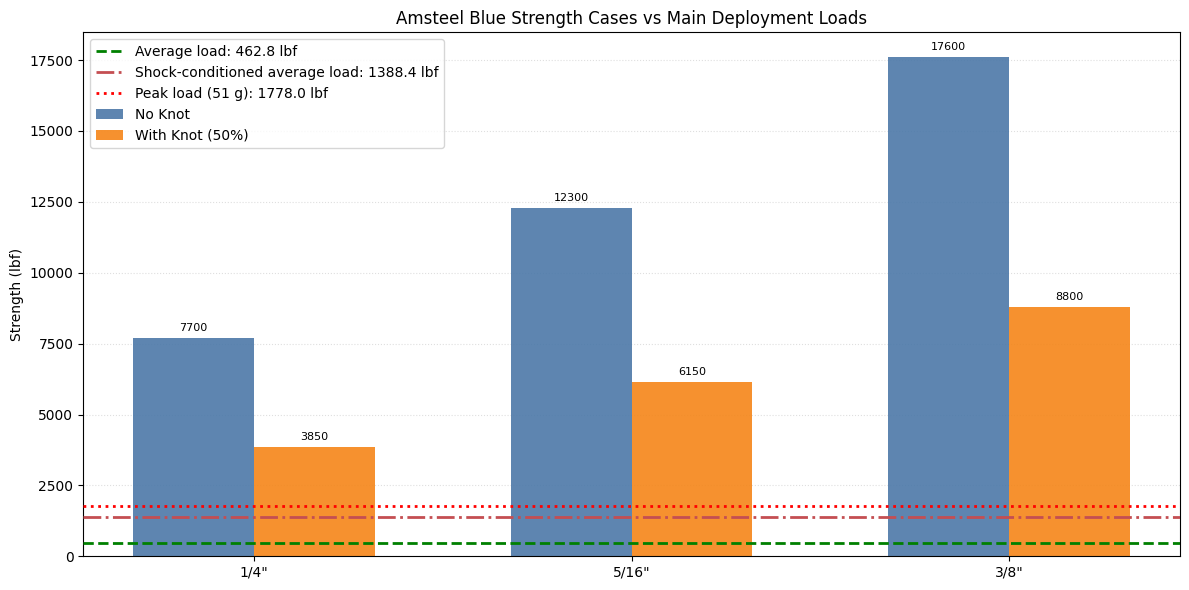

In [12]:
import matplotlib.pyplot as plt
import numpy as np

diameter_labels = list(diameters_main.keys())
knot_treatment_labels = list(knot_treatments_main.keys())
colors = ["#4c78a8", "#f58518"]

x = np.arange(len(diameter_labels))
n_treatments = len(knot_treatment_labels)
width = 0.32
offsets = np.linspace(-(n_treatments - 1) / 2, (n_treatments - 1) / 2, n_treatments) * width

avg_load_lbf = loads_lbf["Average deployment load"]
shock_load_lbf = loads_lbf[f"Shock-conditioned average load (x{shock_load_factor:.1f})"]
peak_load_lbf = loads_lbf[f"Peak load at {max_g_main:.0f} g"]
label_offset = max(strength_lbf.values()) * 0.01

fig, ax = plt.subplots(figsize=(12, 6))

for i, treatment_label in enumerate(knot_treatment_labels):
    vals = [
        diameters_main[diam_label] * knot_treatments_main[treatment_label]
        for diam_label in diameter_labels
    ]
    rects = ax.bar(
        x + offsets[i],
        vals,
        width,
        label=treatment_label,
        color=colors[i],
        alpha=0.9,
        zorder=2,
    )
    for rect, v in zip(rects, vals):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            v + label_offset,
            f"{v:.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.axhline(
    avg_load_lbf,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Average load: {avg_load_lbf:.1f} lbf",
    zorder=3,
)
ax.axhline(
    shock_load_lbf,
    color="#c44e52",
    linestyle="-.",
    linewidth=2,
    label=f"Shock-conditioned average load: {shock_load_lbf:.1f} lbf",
    zorder=3,
)
ax.axhline(
    peak_load_lbf,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Peak load ({max_g_main:.0f} g): {peak_load_lbf:.1f} lbf",
    zorder=3,
)

ax.set_xticks(x)
ax.set_xticklabels(diameter_labels)
ax.set_ylabel("Strength (lbf)")
ax.set_title("Amsteel Blue Strength Cases vs Main Deployment Loads")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.legend()
plt.tight_layout()
plt.show()

## Notes
- Update inputs with your measured pre-main and post-main descent rates from flight data.
- Deployment time is often the largest uncertainty; run sensitivity checks across plausible values.
- In this version, the dynamic shock factor is applied to the average load case, not to rope strength.
- Published line strength can vary by manufacturer and knot/splice method. Use your exact hardware specification when finalizing FoS.


## Drogue Deployment calculations (taking into account horizontal velocities)

In [13]:
# Drogue deployment inputs (edit these for your flight)
mass_lbm_drogue = 35.0  # Rocket mass at drogue deployment, lbm

# Velocity components use a signed convention:
# - vertical: positive downward
# - horizontal: positive along your chosen downrange axis
v_vertical_before_drogue_fts = -15.1
v_vertical_after_drogue_fts = 117.0
v_horizontal_before_drogue_fts = 135.9
v_horizontal_after_drogue_fts = 25.0

deployment_time_drogue_s = 34
max_g_drogue = 18.6
required_fos_drogue = 3.0
knot_efficiency_drogue = 0.50
shock_load_factor_drogue = 3.0

# 1/4 in Amsteel Blue minimum break strength (typical published value)
amsteel_strength_lbf_drogue = 8600.0

# Constants
KG_PER_LBM_DROGUE = 0.45359237
M_PER_FT_DROGUE = 0.3048
N_PER_LBF_DROGUE = 4.4482216152605
g_drogue = 9.80665

# Derived inputs
mass_kg_drogue = mass_lbm_drogue * KG_PER_LBM_DROGUE
v_vertical_before_drogue_mps = v_vertical_before_drogue_fts * M_PER_FT_DROGUE
v_vertical_after_drogue_mps = v_vertical_after_drogue_fts * M_PER_FT_DROGUE
v_horizontal_before_drogue_mps = v_horizontal_before_drogue_fts * M_PER_FT_DROGUE
v_horizontal_after_drogue_mps = v_horizontal_after_drogue_fts * M_PER_FT_DROGUE

diameters_drogue = {
    '1/4"': amsteel_strength_lbf_drogue,
}
knot_treatments_drogue = {
    'No Knot': 1.0,
    'With Knot (50%)': knot_efficiency_drogue,
}

strength_lbf_drogue = {
    f'{diam} {treatment}': base * factor
    for diam, base in diameters_drogue.items()
    for treatment, factor in knot_treatments_drogue.items()
}

In [14]:
# Drogue deployment calculations
import math

speed_before_drogue_mps = math.hypot(
    v_horizontal_before_drogue_mps,
    v_vertical_before_drogue_mps,
)
speed_after_drogue_mps = math.hypot(
    v_horizontal_after_drogue_mps,
    v_vertical_after_drogue_mps,
)

delta_v_vertical_drogue_mps = v_vertical_after_drogue_mps - v_vertical_before_drogue_mps
delta_v_horizontal_drogue_mps = v_horizontal_after_drogue_mps - v_horizontal_before_drogue_mps
delta_v_total_drogue_mps = math.hypot(
    delta_v_horizontal_drogue_mps,
    delta_v_vertical_drogue_mps,
)
a_drogue_mps2 = delta_v_total_drogue_mps / deployment_time_drogue_s
a_drogue_g = a_drogue_mps2 / g_drogue

avg_tension_drogue_N = mass_kg_drogue * (a_drogue_mps2 + g_drogue)
shock_conditioned_tension_drogue_N = avg_tension_drogue_N * shock_load_factor_drogue
peak_tension_drogue_N = mass_kg_drogue * max_g_drogue * g_drogue

loads_drogue_N = {
    "Average drogue deployment load": avg_tension_drogue_N,
    f"Shock-conditioned average load (x{shock_load_factor_drogue:.1f})": shock_conditioned_tension_drogue_N,
    f"Peak load at {max_g_drogue:.0f} g": peak_tension_drogue_N,
}
loads_drogue_lbf = {
    name: value / N_PER_LBF_DROGUE
    for name, value in loads_drogue_N.items()
}

fos_drogue = {
    strength_name: {
        load_name: strength_value / load_value
        for load_name, load_value in loads_drogue_lbf.items()
    }
    for strength_name, strength_value in strength_lbf_drogue.items()
}

print(f"Speed before drogue deployment: {speed_before_drogue_mps:.2f} m/s ({speed_before_drogue_mps / M_PER_FT_DROGUE:.1f} ft/s)")
print(f"Speed after drogue deployment: {speed_after_drogue_mps:.2f} m/s ({speed_after_drogue_mps / M_PER_FT_DROGUE:.1f} ft/s)")
print(f"Vector delta-V across drogue deployment: {delta_v_total_drogue_mps:.2f} m/s ({delta_v_total_drogue_mps / M_PER_FT_DROGUE:.1f} ft/s)")
print(f"Average deceleration magnitude: {a_drogue_mps2:.2f} m/s^2 ({a_drogue_g:.2f} g)")
print()
print("Load cases:")
for name, load_value in loads_drogue_lbf.items():
    print(f"- {name}: {load_value:,.1f} lbf ({load_value * N_PER_LBF_DROGUE:,.0f} N)")
print()
print("Strength cases:")
for name, strength_value in strength_lbf_drogue.items():
    print(f"- {name}: {strength_value:,.0f} lbf ({strength_value * N_PER_LBF_DROGUE:,.0f} N)")

Speed before drogue deployment: 41.68 m/s (136.7 ft/s)
Speed after drogue deployment: 36.47 m/s (119.6 ft/s)
Vector delta-V across drogue deployment: 52.57 m/s (172.5 ft/s)
Average deceleration magnitude: 1.55 m/s^2 (0.16 g)

Load cases:
- Average drogue deployment load: 40.5 lbf (180 N)
- Shock-conditioned average load (x3.0): 121.6 lbf (541 N)
- Peak load at 19 g: 651.0 lbf (2,896 N)

Strength cases:
- 1/4" No Knot: 8,600 lbf (38,255 N)
- 1/4" With Knot (50%): 4,300 lbf (19,127 N)


In [15]:
# Drogue factor-of-safety summary and design check
import pandas as pd

design_strength_case_drogue = '1/4" With Knot (50%)'
design_load_case_drogue = f"Peak load at {max_g_drogue:.0f} g"

rows_drogue = []
for strength_name, row in fos_drogue.items():
    for load_name, value in row.items():
        rows_drogue.append(
            {
                "Strength case": strength_name,
                "Load case": load_name,
                "FoS": round(value, 2),
                "Target FoS": required_fos_drogue,
                "Meets target": "PASS" if value >= required_fos_drogue else "CHECK",
            }
        )

fos_table_drogue = pd.DataFrame(rows_drogue)
fos_table_drogue["Design case"] = (
    (fos_table_drogue["Strength case"] == design_strength_case_drogue)
    & (fos_table_drogue["Load case"] == design_load_case_drogue)
).map({True: "<- selected", False: ""})

design_row_drogue = fos_table_drogue.loc[
    (fos_table_drogue["Strength case"] == design_strength_case_drogue)
    & (fos_table_drogue["Load case"] == design_load_case_drogue)
] .iloc[0]
design_fos_drogue = float(design_row_drogue["FoS"])

display(fos_table_drogue)

print()
if design_fos_drogue >= required_fos_drogue:
    print(
        f"PASS: {design_strength_case_drogue} vs {design_load_case_drogue} gives FoS = "
        f"{design_fos_drogue:.2f}, meeting target >= {required_fos_drogue:.1f}"
    )
else:
    print(
        f"CHECK DESIGN: {design_strength_case_drogue} vs {design_load_case_drogue} gives FoS = "
        f"{design_fos_drogue:.2f}, below target >= {required_fos_drogue:.1f}"
    )

,Strength case,Load case,FoS,Target FoS,Meets target,Design case
0,"1/4"" No Knot",Average drogue deployment load,212.25,3.0,PASS,
1,"1/4"" No Knot",Shock-conditioned average load (x3.0),70.75,3.0,PASS,
2,"1/4"" No Knot",Peak load at 19 g,13.21,3.0,PASS,
3,"1/4"" With Knot (50%)",Average drogue deployment load,106.12,3.0,PASS,
4,"1/4"" With Knot (50%)",Shock-conditioned average load (x3.0),35.37,3.0,PASS,
5,"1/4"" With Knot (50%)",Peak load at 19 g,6.61,3.0,PASS,<- selected



PASS: 1/4" With Knot (50%) vs Peak load at 19 g gives FoS = 6.61, meeting target >= 3.0


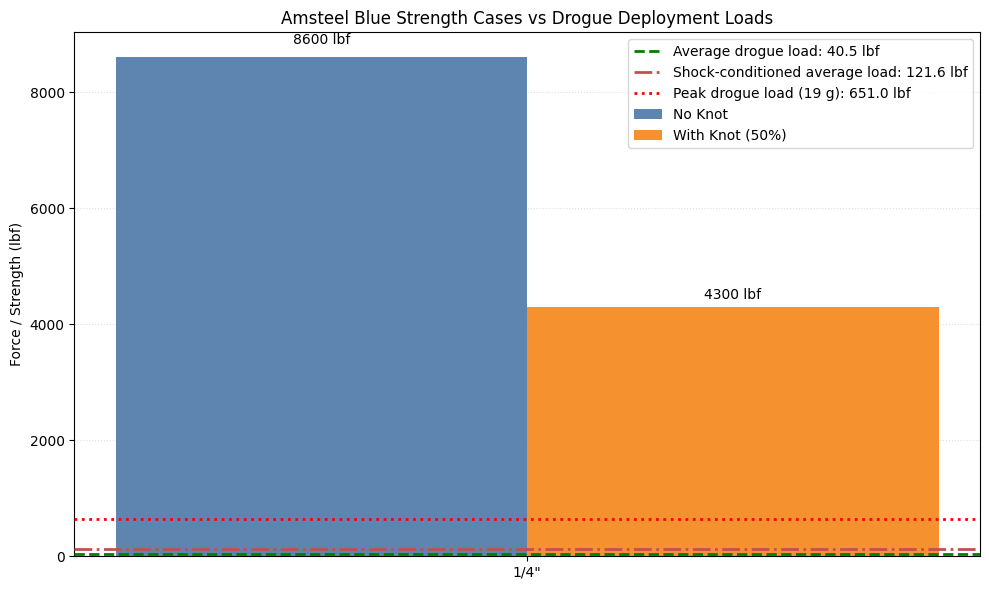

In [16]:
import matplotlib.pyplot as plt
import numpy as np

diameter_labels_drogue = list(diameters_drogue.keys())
knot_treatment_labels_drogue = list(knot_treatments_drogue.keys())
colors_drogue = ["#4c78a8", "#f58518"]

x_drogue = np.arange(len(diameter_labels_drogue))
n_treatments_drogue = len(knot_treatment_labels_drogue)
width_drogue = 0.32
offsets_drogue = np.linspace(
    -(n_treatments_drogue - 1) / 2,
    (n_treatments_drogue - 1) / 2,
    n_treatments_drogue,
) * width_drogue

avg_load_drogue_lbf = loads_drogue_lbf["Average drogue deployment load"]
shock_load_drogue_lbf = loads_drogue_lbf[
    f"Shock-conditioned average load (x{shock_load_factor_drogue:.1f})"
]
peak_load_drogue_lbf = loads_drogue_lbf[f"Peak load at {max_g_drogue:.0f} g"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, treatment_label in enumerate(knot_treatment_labels_drogue):
    values = [
        diameters_drogue[diameter_label] * knot_treatments_drogue[treatment_label]
        for diameter_label in diameter_labels_drogue
    ]
    bars = ax.bar(
        x_drogue + offsets_drogue[i],
        values,
        width_drogue,
        label=treatment_label,
        color=colors_drogue[i],
        alpha=0.9,
        zorder=2,
    )
    label_offset_drogue = max(values) * 0.02
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + label_offset_drogue,
            f"{value:.0f} lbf",
            ha="center",
            va="bottom",
            fontsize=10,
        )

ax.axhline(
    avg_load_drogue_lbf,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Average drogue load: {avg_load_drogue_lbf:.1f} lbf",
    zorder=3,
)
ax.axhline(
    shock_load_drogue_lbf,
    color="#c44e52",
    linestyle="-.",
    linewidth=2,
    label=f"Shock-conditioned average load: {shock_load_drogue_lbf:.1f} lbf",
    zorder=3,
)
ax.axhline(
    peak_load_drogue_lbf,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Peak drogue load ({max_g_drogue:.0f} g): {peak_load_drogue_lbf:.1f} lbf",
    zorder=3,
)

ax.set_xticks(x_drogue)
ax.set_xticklabels(diameter_labels_drogue)
ax.set_ylabel("Force / Strength (lbf)")
ax.set_title("Amsteel Blue Strength Cases vs Drogue Deployment Loads")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.legend()
plt.tight_layout()
plt.show()

## Drogue Notes
- Enter signed velocity components so the vector delta-V includes both vertical and horizontal changes.
- If you only know magnitudes, keep the signs consistent with one chosen axis and direction convention.
- The dynamic shock factor is applied to the average drogue load case, while the peak-load case still uses the separate `max_g_drogue` assumption.
- Knot assumptions only change the available rope strength, not the applied load.